<a href="https://colab.research.google.com/github/rhyan10/X-MACE/blob/X-MACE_socs/tutorial-summer-school.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# X-MACE Tutorial: From Dataset to Nonadiabatic Dynamics

**X-MACE** models excited-state potential energy surfaces — including conical
intersections, non-adiabatic couplings (NACs) and spin-orbit couplings (SOCs). It extends
[MACE](https://github.com/ACEsuit/mace) with **Deep Sets**, giving a smooth representation
of inherently non-smooth multi-state surfaces.

**Part 1 — The data** (sections 1-6)
Read an extended XYZ file, understand `atoms.info`, verify shapes, and look at the
conical-intersection region.

**Part 2 — Training** (sections 7-14)
Install X-MACE, understand the two model variants, build a correct training command,
run a short job, and read the results.

**Part 3 — Validation** (sections 15-17)
Load the trained model as an ASE calculator, predict energies, forces and couplings
on sample frames, and compare against the reference data in parity plots.

**Part 4 — Nonadiabatic dynamics** (sections 18-22)
Build SHARC 4, plug the trained model in as its electronic-structure engine, and run an
ensemble of surface hopping trajectories — ending with the ultrafast S2 -> S1 -> S0
population decay of CH2NH2+ through the conical intersections seen in Part 1.

**Part 5 — Absorption spectra** (sections 23-26)
Train a model that predicts excitation energies and oscillator strengths for propene,
and build a UV/Vis absorption spectrum with the nuclear ensemble method.

The first three parts are **derived from the dataset itself** — atom count, number of
states, which properties exist, and which key names they use. Point `DATA_FILE` at a
different file and both the analysis and the training command adapt automatically. Part 4
then takes the model you trained here all the way to real excited-state dynamics.

> Barrett et al., [arXiv:2502.12870](https://arxiv.org/abs/2502.12870) (2025) ·
> [github.com/rhyan10/X-MACE](https://github.com/rhyan10/X-MACE)

---

# Part 1 — The Dataset

## 1. Setup

Colab starts from a clean machine every time, so we install and import what the notebook
needs up front:

- **ASE** (Atomic Simulation Environment) - a Python toolkit for building, reading, and
  manipulating atomic structures. We use it mainly for `ase.io` to parse the trajectory
  file and for its `Atoms` objects to hold each frame. It isn't preinstalled on Colab.
- **NumPy** - the array library everything else is built on; positions, energies, and
  forces all come out of ASE as NumPy arrays.

The cell then reports the ASE and PyTorch versions and sets `DEVICE` to the GPU if one is
available. CPU is fine, training is just slower.

In [1]:
!pip install -q ase

import ase, ase.io
import numpy as np

print("ASE version:", ase.__version__)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print("PyTorch    :", torch.__version__)
except ImportError:
    DEVICE = "cpu"

print("Device     :", DEVICE)
if DEVICE == "cpu":
    print("\nNo GPU available. Everything here still works — training is just slower.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 20.1 MB/s eta 0:00:00
ASE version: 3.29.0
PyTorch    : 2.11.0+cpu
Device     : cpu

No GPU available. Everything here still works — training is just slower.


## 1.1 Get the dataset

The tutorial uses `ch2nh2.xyz` (~10 MB), an XYZ file holding the
geometries and reference labels for every frame, the only input the rest of the
notebook needs apart from the final spectra example.

The cell tries three sources in order: a copy already in the working directory, a download from `DATA_URL`, then a manual Colab upload. The download only counts as successful if `wget` exits cleanly *and* the file is non-empty, which catches the case where a 404 page gets saved under the right name. A closing `assert` fails immediately if all three fall through, instead of letting a cryptic error appear several cells later.

In [2]:
import os

DATA_FILE = "ch2nh2.xyz"
DATA_URL  = "https://raw.githubusercontent.com/rhyan10/X-MACE/X-MACE_socs/tutorials/ch2nh2.xyz"

if os.path.exists(DATA_FILE):
    print(f"Found {DATA_FILE} already.")
else:
    got = False
    if DATA_URL:
        rc = os.system(f"wget -q -O {DATA_FILE} {DATA_URL}")
        got = rc == 0 and os.path.getsize(DATA_FILE) > 0
        print("Downloaded." if got else "Download failed — falling back to upload.")
    if not got:
        if os.path.exists(DATA_FILE):
            os.remove(DATA_FILE)
        from google.colab import files
        files.upload()

assert os.path.exists(DATA_FILE), f"{DATA_FILE} is missing — cannot continue."
print("Size on disk:", round(os.path.getsize(DATA_FILE) / 1e6, 2), "MB")

Downloaded.
Size on disk: 10.68 MB


## 2. Reading the File

`ase.io.read` parses the extended-XYZ file into a list of `Atoms` objects, ASE's core structure, bundling positions, chemical symbols,
and cell information for one frame, with the reference labels attached in `atoms.info`
and `atoms.arrays`.

The second argument is a slice string: pass `":"` to read **all** frames, or `":500"` for the first 500 frames for example.

In [3]:
db = ase.io.read(DATA_FILE, ":")
atoms = db[0]

print(f"Total frames loaded : {len(db)}")
print(f"Type of each element: {type(atoms)}")

Total frames loaded : 4000
Type of each element: <class 'ase.atoms.Atoms'>


## 3. Basic Atoms Properties

Every `Atoms` object exposes the same handful of attributes describing *what* the
molecule is and *where* its atoms sit. Here `atoms` is frame 0, the cation
CH₂NH₂, six atoms in total.

The key one for modelling is `positions`: an `(N_atoms, 3)` NumPy array of Cartesian
coordinates in Ångström, ordered to match `symbols`, so row i is the position of atom
i. Every frame in this dataset shares the same atom ordering, only the coordinates
change.

In [4]:
print("Number of atoms    :", len(atoms))
print("Chemical formula   :", atoms.get_chemical_formula())
print("Chemical symbols   :", list(atoms.symbols))
print("Positions shape    :", atoms.positions.shape)   # (N_atoms, 3)

Number of atoms    : 6
Chemical formula   : CH4N
Chemical symbols   : ['C', 'N', 'H', 'H', 'H', 'H']
Positions shape    : (6, 3)


## 4. What's Actually in `atoms.info`?

`atoms.info` is a plain Python `dict` holding everything from the extXYZ comment line.
In this dataset it contains the reference labels the model is trained against.

Key names vary between X-MACE datasets: `ch2nh2.xyz` stores NACs under `REF_nacs`. So it's worth printing the keys for whatever file you've loaded rather than copying them from another example.

The shapes are also informative: `REF_energy` is `(1, 3)` — three electronic states and both `REF_forces` and `smooth_nacs` are `(6, 3, 3)`, i.e. one 3-vector per atom per state.

In [5]:
print(f"{'key':22s} {'shape':16s} dtype")
print("-" * 50)
for k, v in atoms.info.items():
    arr = np.asarray(v)
    print(f"{k:22s} {str(arr.shape):16s} {arr.dtype}")

key                    shape            dtype
--------------------------------------------------
REF_energy             (1, 3)           float64
REF_forces             (6, 3, 3)        float64
REF_nacs               (6, 3, 3)        float64


## 5. Working Out the Dataset Dimensions

Rather than hardcoding numbers, this cell reads them off the data:

- `N` - atoms per frame
- `n_states` - electronic states, from the trailing axis of the energy array
- `n_pairs` - unique state pairs, `n_states x (n_states - 1) / 2`; this is how many NAC
  vectors exist, and what `--nac_num` must be set to

The four key names are declared at the top. These are the ones `ch2nh2.xyz` uses, which
also happen to be X-MACE's defaults edit them here and the rest of the notebook follows. Keys that aren't
in the file resolve to `None`, so the NAC and SOC sections below simply skip themselves.

In [6]:
from itertools import combinations

ENERGY_KEY = 'REF_energy'
FORCES_KEY = 'REF_forces'
NACS_KEY   = 'REF_nacs'
SOCS_KEY   = 'REF_socs'

energy   = np.array(atoms.info[ENERGY_KEY])
N        = len(atoms)
n_states = energy.shape[-1]
n_pairs  = n_states * (n_states - 1) // 2

# None when the dataset doesn't carry that property — later cells test for it.
HAS_FORCES = FORCES_KEY in atoms.info
NAC_KEY    = NACS_KEY if NACS_KEY in atoms.info else None
SOC_KEY    = SOCS_KEY if SOCS_KEY in atoms.info else None
HAS_SOCS   = SOC_KEY is not None
N_SOC      = int(np.array(atoms.info[SOC_KEY]).size) if SOC_KEY else 0

nac_note = f'{NAC_KEY}   -> --nacs_key="{NAC_KEY}"' if NAC_KEY else 'none found'
soc_note = f'yes, n_soc={N_SOC}  -> --soc_num={N_SOC}' if HAS_SOCS else 'no'

print(f"N_atoms   : {N}")
print(f"n_states  : {n_states}      -> --n_energies={n_states}")
print(f"n_pairs   : {n_pairs}      -> --nac_num={n_pairs}")
print(f"forces    : {'yes' if HAS_FORCES else 'no'}")
print(f"NAC key   : {nac_note}")
print(f"SOCs      : {soc_note}")

N_atoms   : 6
n_states  : 3      -> --n_energies=3
n_pairs   : 3      -> --nac_num=3
forces    : yes
NAC key   : REF_nacs   -> --nacs_key="REF_nacs"
SOCs      : no


### Expected shapes

| Key | Shape | Meaning |
|---|---|---|
| `REF_energy` | `(1, n_states)` | one geometry x state energies |
| `REF_forces` | `(N, n_states, 3)` | atoms x states x xyz |
| NAC key | `(N, n_pairs, 3)` | atoms x state pairs x xyz |
| SOC key | `(1, n_soc)` | flat SOC vector, if present |

## 6. Inspecting Each Property

### 6.1 Energies
Inspect the electronic energies for a single frame. REF_energy is stored frame-level in atoms.info with shape (1, n_states), one row of adiabatic energies ordered S0, S1, S2. We flatten, sort as a sanity check (for adiabatic energies sorting should change nothing), and print the S1–S0 gap.

In [7]:
print("shape  :", energy.shape)
print("values :", energy)

ev = np.sort(energy.ravel())
print("\nsorted :", ev)
print("S1-S0 gap at this geometry:", ev[1] - ev[0])

shape  : (1, 3)
values : [[-2576.01867378 -2567.9484766  -2566.66423094]]

sorted : [-2576.01867378 -2567.9484766  -2566.66423094]
S1-S0 gap at this geometry: 8.07019717499088


### 6.2 Forces
Inspect the excited-state forces. REF_forces is also stored in atoms.info as nested JSON with shape (n_atoms, n_states, 3): entry [a, s] is the force on atom a when the system evolves on adiabatic surface s.

In [8]:
if HAS_FORCES:
    forces = np.array(atoms.info[FORCES_KEY])
    print("forces shape :", forces.shape, f"  expected ({N}, {n_states}, 3)")
    print("state-first  :", forces.transpose(1, 0, 2).shape)
    print("largest |force| in this frame:", np.abs(forces).max())
else:
    print("No forces in this dataset.")

forces shape : (6, 3, 3)   expected (6, 3, 3)
state-first  : (3, 6, 3)
largest |force| in this frame: 19.1617256556


### 6.3 Nonadiabatic Couplings

Inspect the couplings between electronic states. Unlike energies and forces, NACs are indexed by state pair, not by state, with n_states states there are n_pairs = n(n−1)/2 of them, ordered (0,1), (0,2), (1,2), … (upper-triangular convention). REF_nacs has shape (n_atoms, n_pairs, 3): entry [a, p, :] is the coupling vector on atom a for pair p.

In [9]:
if NAC_KEY:
    nacs = np.array(atoms.info[NAC_KEY])
    print(f"{NAC_KEY} shape :", nacs.shape, f"  expected ({N}, {n_pairs}, 3)")

    if n_states == n_pairs:
        print(f"\nNote: with {n_states} states, n_pairs is also {n_pairs}, so forces and")
        print("NACs have identical shapes. Don't rely on shape alone to tell them apart.")

    print("\nstate pairs (column order):")
    for i, (a, b) in enumerate(combinations(range(n_states), 2)):
        print(f"  column {i}:  S{a} - S{b}   |max| = {np.abs(nacs[:, i, :]).max():.6f}")
else:
    print("No NAC key found in this dataset.")

REF_nacs shape : (6, 3, 3)   expected (6, 3, 3)

Note: with 3 states, n_pairs is also 3, so forces and
NACs have identical shapes. Don't rely on shape alone to tell them apart.

state pairs (column order):
  column 0:  S0 - S1   |max| = 0.023236
  column 1:  S0 - S2   |max| = 0.146203
  column 2:  S1 - S2   |max| = 0.655503


### 6.4 Spin-Orbit Couplings

Only present in datasets that include triplets.

In [10]:
if HAS_SOCS:
    socs = np.array(atoms.info[SOC_KEY])
    print(f"{SOC_KEY} shape :", socs.shape)
    print("n_soc :", N_SOC, " -> use for --soc_num")
else:
    print("No SOCs in this dataset — omit --compute_socs when training.")

No SOCs in this dataset — omit --compute_socs when training.


## 7. Sanity Check Across All Frames

Validate the full dataset, not just the first frame. check_frame compares every property key against its expected shape - (1, n_states) for energies, (n_atoms, n_states, 3) for forces, (n_atoms, n_pairs, 3) for NACs, and frame 0's shape for SOCs - flagging keys that are missing or mis-shaped. Only properties this dataset actually contains are checked, so the same cell works across singlets-only and SOC-bearing files. Frame 0 is shown in detail; the remaining frames are scanned silently and any offenders are listed by index. A clean scan means every frame can be batched with the same tensor shapes downstream — the failure mode this catches is a partially written or concatenated file where a few frames carry different state counts.

In [11]:
def check_frame(a, verbose=False):
    problems, n = [], len(a)

    exp = {ENERGY_KEY: (1, n_states)}
    if HAS_FORCES:
        exp[FORCES_KEY] = (n, n_states, 3)
    if NAC_KEY:
        exp[NAC_KEY] = (n, n_pairs, 3)
    if HAS_SOCS:
        exp[SOC_KEY] = np.array(db[0].info[SOC_KEY]).shape

    for key, want in exp.items():
        if key not in a.info:
            problems.append(f"{key}: missing")
            if verbose:
                print(f"  [--] {key:22s} missing")
            continue
        got = np.array(a.info[key]).shape
        if got != want:
            problems.append(f"{key}: expected {want}, got {got}")
        if verbose:
            print(f"  [{'OK ' if got == want else 'BAD'}] {key:22s} "
                  f"expected {str(want):16s} got {got}")
    return problems


print("Frame 0 in detail:")
check_frame(db[0], verbose=True)

print("\nScanning all frames...")
bad = {i: p for i, a in enumerate(db) if (p := check_frame(a))}

if not bad:
    print(f"All {len(db)} frames have consistent shapes.")
else:
    print(f"{len(bad)} of {len(db)} frames have problems. First few:")
    for i, probs in list(bad.items())[:5]:
        print(f"  frame {i}: {'; '.join(probs)}")

Frame 0 in detail:
  [OK ] REF_energy             expected (1, 3)           got (1, 3)
  [OK ] REF_forces             expected (6, 3, 3)        got (6, 3, 3)
  [OK ] REF_nacs               expected (6, 3, 3)        got (6, 3, 3)

Scanning all frames...
All 4000 frames have consistent shapes.


## 8. Energy Gaps and Coupling Magnitudes

Two diagnostic plots for how close this dataset gets to degeneracy. The left
panel histograms the S1–S0 gap across all frames: most geometries sit at
comfortable gaps, and the size of the left tail shows how much (or how little)
of the data samples the near-degenerate region. The right panel scatters each
frame's largest |NAC| against its gap on a log scale, couplings grow as the
gap shrinks, the 1/ΔE behavior that makes this region hard to learn directly
and motivates storing gap-multiplied smooth NACs instead.

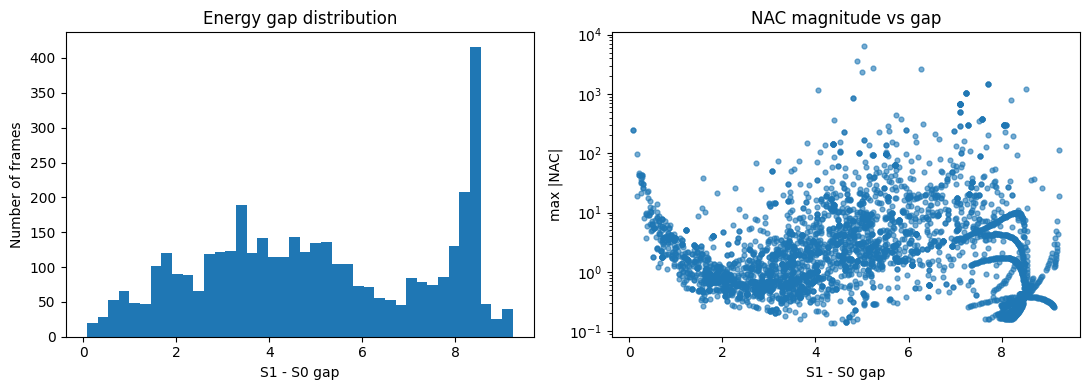

Frames        : 4000
Energy range  : -2577.1798 to -2562.6868
Smallest gap  : 0.081624  (frame 2696)
Largest |force|: 35.5897  (frame 3916)


In [12]:
import matplotlib.pyplot as plt

gaps, min_e, max_f = [], [], []
for f in db:
    e = np.sort(np.array(f.info[ENERGY_KEY]).ravel())
    min_e.append(e[0])
    gaps.append(e[1] - e[0] if len(e) > 1 else np.nan)
    if HAS_FORCES:
        max_f.append(np.abs(np.array(f.info[FORCES_KEY])).max())

gaps, min_e = np.array(gaps), np.array(min_e)

fig, axes = plt.subplots(1, 2 if NAC_KEY else 1,
                         figsize=(11 if NAC_KEY else 6, 4), squeeze=False)
axes[0][0].hist(gaps, bins=40)
axes[0][0].set_xlabel("S1 - S0 gap")
axes[0][0].set_ylabel("Number of frames")
axes[0][0].set_title("Energy gap distribution")

if NAC_KEY:
    nac_mag = np.array([np.abs(np.array(f.info[NAC_KEY])).max() for f in db])
    axes[0][1].scatter(gaps, nac_mag, s=12, alpha=0.6)
    axes[0][1].set_xlabel("S1 - S0 gap")
    axes[0][1].set_ylabel("max |NAC|")
    axes[0][1].set_yscale("log")
    axes[0][1].set_title("NAC magnitude vs gap")

plt.tight_layout()
plt.show()

print(f"Frames        : {len(db)}")
print(f"Energy range  : {min_e.min():.4f} to {min_e.max():.4f}")
print(f"Smallest gap  : {gaps.min():.6f}  (frame {gaps.argmin()})")
if HAS_FORCES:
    max_f = np.array(max_f)
    print(f"Largest |force|: {max_f.max():.4f}  (frame {max_f.argmax()})")

---

# Part 2 — Training X-MACE

## 9. Installing X-MACE

Cloning plus `pip install .`. Colab already ships a compatible torch, so this usually takes 2-4 minutes.

Set `INSTALL_XMACE = False` if you only want Part 1, or if you have already run this once
in this session.

In [13]:
INSTALL_XMACE = True   #@param {type:"boolean"}

import os

def xmace_ready():
    """True if the mace package actually imports."""
    import importlib
    try:
        importlib.invalidate_caches()
        importlib.import_module("mace")
        return True
    except ImportError:
        return False

if not INSTALL_XMACE:
    print("Skipping install (INSTALL_XMACE = False).")
elif xmace_ready():
    print("X-MACE is already installed and importable.")
else:
    if not os.path.exists("X-MACE"):
        !git clone -q --depth 1 -b X-MACE_socs https://github.com/rhyan10/X-MACE.git
    !cd X-MACE && pip install .

    if xmace_ready():
        print("\nX-MACE installed and importable.")
    else:
        print("\nInstall finished but 'import mace' still fails.")
        print("This is normal when pip replaced a preloaded package.")
        print("Go to Runtime > Restart session, then re-run this cell.")

Processing /content/X-MACE
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.3 MB/s eta 0:00:00
  Created wheel for mace-torch: filename=mace_torch-0.3.6-py3-none-any.whl size=120565 sha256=fd690800dee64a02e6740316f844943262b84b7307ee718a039145fc4190365e
  Stored in directory: /root/.cache/pip/wheels/e5/42/6b/2a2341231c5f11a0aaa31efc197adac805024fbb30d6d2f2b3
  Created wheel for python-hostlist: filename=python_hostlist-2.3.0-py3-none-any.whl size=39449 sha256=0fe94a2ff43e30358d46de8bdea1dc71438df1b306d83ad8f57574f4eced5052
  Stored in directory: /root/.cache/pip/wheels/02/e4/34/75fc0cd5b7889d8cc4ce6fb2f74c9fd17b3c6138cb03832481
Successfully b

## 10. The Two Model Variants

| `--model` | Name | What it does |
|---|---|---|
| `AutoencoderExcitedMACE` | **X-MACE** | Adds a matrix-diagonalisation step via an autoencoder. Better energy accuracy near conical intersections.|
| `ExcitedMACE` | **E-MACE** | Standard multi-state readout, no diagonalisation. Faster, and required for NAC and SOC training. |

Since this dataset has NACs, the sections below use `AutoencoderExcitedMACE`. Switch to
`ExcitedMACE` if you would like.

## 11. Building the Training Command

Assemble the command line for `run_train.py` from a handful of tunable form
fields. The dropdowns and sliders control the choices you'd actually vary
between runs — direct energy prediction (`ExcitedMACE`) vs the autoencoder
variant (`AutoencoderExcitedMACE`), the hidden irreps, cutoff radius, learning
rate, batch size, and epoch budget — while everything tied to the dataset is
filled in automatically from earlier sections: `n_energies` from the state
count, `--nac_num` and `--nacs_key` from the detected NAC layout, SOC flags
only if the file carries them, and the device from section 1. The cell prints
the full command rather than running it, so you can inspect every flag (or
copy it to a terminal) before committing to a training run.

In [29]:
#@title Training configuration { run: "auto" }
MODEL        = "ExcitedMACE"   #@param ["ExcitedMACE", "AutoencoderExcitedMACE"]
MAX_EPOCHS   = 1               #@param {type:"slider", min:1, max:200, step:1}
BATCH_SIZE   = 10              #@param {type:"integer"}
HIDDEN       = "128x0e + 128x1o" #@param ["32x0e + 32x1o", "128x0e + 128x1o"]
R_MAX        = 5.0             #@param {type:"number"}
LR           = 0.01          #@param {type:"number"}
TRAIN_NACS   = True            #@param {type:"boolean"}
NAME         = "tutorial_run"  #@param {type:"string"}

mlp = HIDDEN.split("+")[0].strip()          # MLP_irreps matches the scalar part
use_nacs = TRAIN_NACS and NAC_KEY is not None

flags = [
    f'--name="{NAME}"',
    f'--train_file="{os.path.abspath(DATA_FILE)}"',
    "--seed=100",
    "--valid_fraction=0.1",
    "--E0s='average'",
    f'--model="{MODEL}"',
    f"--r_max={R_MAX}",
    f"--batch_size={BATCH_SIZE}",
    f"--n_energies={n_states}",          # from the data
    "--correlation=3",
    f"--max_num_epochs={MAX_EPOCHS}",
    "--ema",
    f"--lr={LR}",
    "--ema_decay=0.99",
    '--default_dtype="float32"',
    f"--device={DEVICE}",                # cpu or cuda, detected in section 1
    f'--hidden_irreps="{HIDDEN}"',
    f"--MLP_irreps='{mlp}'",
    "--num_radial_basis=8",
    "--num_interactions=2",
    "--energy_weight=100.0",
    "--forces_weight=100.0" if HAS_FORCES else "--forces_weight=0.0",
    '--error_table="EnergyNacsDipoleMAE"',
]

if use_nacs:
    flags += ["--compute_nacs",
              f"--nac_num={n_pairs}",        # from the data
              f'--nacs_key="{NAC_KEY}"']     # from the data
if HAS_SOCS:
    flags += ["--compute_socs", f"--soc_num={N_SOC}"]

CMD = "python scripts/run_train.py \\\n  " + " \\\n  ".join(flags)
print(CMD)

python scripts/run_train.py \
  --name="tutorial_run" \
  --train_file="/content/ch2nh2.xyz" \
  --seed=100 \
  --valid_fraction=0.1 \
  --E0s='average' \
  --model="ExcitedMACE" \
  --r_max=5.0 \
  --batch_size=10 \
  --n_energies=3 \
  --correlation=3 \
  --max_num_epochs=1 \
  --ema \
  --lr=0.0001 \
  --ema_decay=0.99 \
  --default_dtype="float32" \
  --device=cpu \
  --hidden_irreps="128x0e + 128x1o" \
  --MLP_irreps='128x0e' \
  --num_radial_basis=8 \
  --num_interactions=2 \
  --energy_weight=100.0 \
  --forces_weight=100.0 \
  --error_table="EnergyNacsDipoleMAE" \
  --compute_nacs \
  --nac_num=3 \
  --nacs_key="REF_nacs"


### What the key flags mean

| Flag | Meaning |
|---|---|
| `--n_energies` | Number of electronic states to model |
| `--r_max` | Cutoff radius in Å — atoms beyond this don't communicate directly |
| `--hidden_irreps` | Representation size and angular order. `128x0e + 128x1o` is large; `32x0e + 32x1o` trains fast |
| `--num_interactions` | Message-passing layers; 2 gives a receptive field of `2 x r_max` |
| `--correlation` | Body order per layer|
| `--energy_weight` / `--forces_weight` / `--nacs_weight` | Relative weight of each term in the loss |
| `--ema` / `--ema_decay` | Exponential moving average of weights, stabilises training |
| `--E0s='average'` | Isolated-atom energies estimated from the dataset average |
| `--compute_nacs` / `--nac_num` / `--nacs_key` | Enable the NAC head, how many vectors, and which dataset key |
| `--foundation_model` | Initialise from a pre-trained ground-state MACE (see section 13) |

**Tip:** to train only one property, keep everything in the dataset and set the other
loss weights to `0.0` — X-MACE expects energies to be present regardless.

## 12. Running It

A few epochs on this dataset is enough to see the loss move, that's the goal here, not a
converged model. On CPU, keep `MAX_EPOCHS` small and `HIDDEN` at `32x0e + 32x1o`.

Output streams below and is also written to `results/`. Checkpoints land in
`checkpoints/`.

In [15]:
RUN_TRAINING = True   #@param {type:"boolean"}

if RUN_TRAINING and xmace_ready():
    import subprocess, sys
    proc = subprocess.Popen(CMD.replace("\\\n", " "), shell=True, cwd="X-MACE",
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end="")
    proc.wait()
    print(f"\n--- finished with exit code {proc.returncode} ---")
elif not xmace_ready():
    print("X-MACE is not importable — run section 9, and restart the session if asked.")
else:
    print("Set RUN_TRAINING = True to launch.")

2026-07-29 12:30:37.683 INFO: ===========VERIFYING SETTINGS===========
2026-07-29 12:30:37.684 INFO: MACE version: 0.3.6
2026-07-29 12:30:37.685 INFO: Using CPU
2026-07-29 12:30:38.077 INFO: 
2026-07-29 12:30:38.077 INFO: ===========LOADING INPUT DATA===========
2026-07-29 12:30:41.603 INFO: Using random 10% of training set for validation with indices saved in: ./valid_indices_100.txt
2026-07-29 12:30:41.615 INFO: Atomic Numbers used: [np.int64(1), np.int64(6), np.int64(7)]
2026-07-29 12:30:41.615 INFO: Isolated Atomic Energies (E0s) not in training file, using command line argument
2026-07-29 12:30:41.615 INFO: Computing average Atomic Energies using least squares regression
2026-07-29 12:30:41.669 INFO: Atomic Energies used (z: eV): {1: -570.9832860137639, 6: -142.74582150344006, 7: -142.74582150344006}
2026-07-29 12:30:44.177 INFO: 
2026-07-29 12:30:44.178 INFO: ===========MODEL DETAILS===========
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarnin

## 13. Transfer Learning from a Foundation Model

X-MACE can start from a pre-trained ground-state MACE (e.g. `medium_off` from MACE-OFF23).
Only the final DeepSets readout is reinitialised — the message-passing kernels, radial
basis and equivariant features are kept. This cuts the amount of excited-state data needed
and generalises better to molecules outside the training set.

Add one flag to the command from section 11:

In [30]:
transfer_flags = flags + ['--foundation_model="medium_off"']
TRANSFER_CMD = ("python scripts/run_train.py \\\n  "
                + " \\\n  ".join(f.replace(f'"{NAME}"', f'"{NAME}_transfer"')
                                for f in transfer_flags))
print(TRANSFER_CMD)

RUN_TRANSFER = True   #@param {type:"boolean"}

if RUN_TRANSFER and not HIDDEN.startswith("128"):
    print('medium_off is a 128-channel model — set HIDDEN = "128x0e + 128x1o"')
    print('in section 11, re-run that cell, then re-run section 13 and this one.')
elif RUN_TRANSFER and xmace_ready():
    import subprocess
    proc = subprocess.Popen(TRANSFER_CMD.replace("\\\n", " "), shell=True, cwd="X-MACE",
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end="")
    proc.wait()
    print(f"\n--- finished with exit code {proc.returncode} ---")
elif not xmace_ready():
    print("X-MACE is not importable — run section 9 first.")
else:
    print("Set RUN_TRANSFER = True to launch.")

python scripts/run_train.py \
  --name="tutorial_run_transfer" \
  --train_file="/content/ch2nh2.xyz" \
  --seed=100 \
  --valid_fraction=0.1 \
  --E0s='average' \
  --model="ExcitedMACE" \
  --r_max=5.0 \
  --batch_size=10 \
  --n_energies=3 \
  --correlation=3 \
  --max_num_epochs=1 \
  --ema \
  --lr=0.0001 \
  --ema_decay=0.99 \
  --default_dtype="float32" \
  --device=cpu \
  --hidden_irreps="128x0e + 128x1o" \
  --MLP_irreps='128x0e' \
  --num_radial_basis=8 \
  --num_interactions=2 \
  --energy_weight=100.0 \
  --forces_weight=100.0 \
  --error_table="EnergyNacsDipoleMAE" \
  --compute_nacs \
  --nac_num=3 \
  --nacs_key="REF_nacs" \
  --foundation_model="medium_off"
2026-07-29 12:48:02.730 INFO: ===========VERIFYING SETTINGS===========
2026-07-29 12:48:02.730 INFO: MACE version: 0.3.6
2026-07-29 12:48:02.731 INFO: Using CPU
2026-07-29 12:48:02.811 INFO: Using foundation model mace-off-2023 medium as initial checkpoint. ASL license.
The model is distributed under the Academic So

## 14. Reading the Training Output

`--error_table="EnergyNacsDipoleMAE"` writes a per-property MAE table at each evaluation
step. The helper below pulls the loss curves out of the log.

Result files found: ['X-MACE/results/tutorial_run_run-100_train.txt', 'X-MACE/results/tutorial_run_transfer_run-100_train.txt']

Eval entries in tutorial_run_transfer_run-100_train.txt:
  line     0 | run start | loss 3.177e+02 | mae_e 3.34 | mae_f 2.00 | mae_nacs 0.38
  line   361 |   epoch 0 | loss 6.975e+01 | mae_e 0.67 | mae_f 1.15 | mae_nacs 0.38

Plotting tutorial_run_transfer_run-100_train.txt: 1 epoch(s)


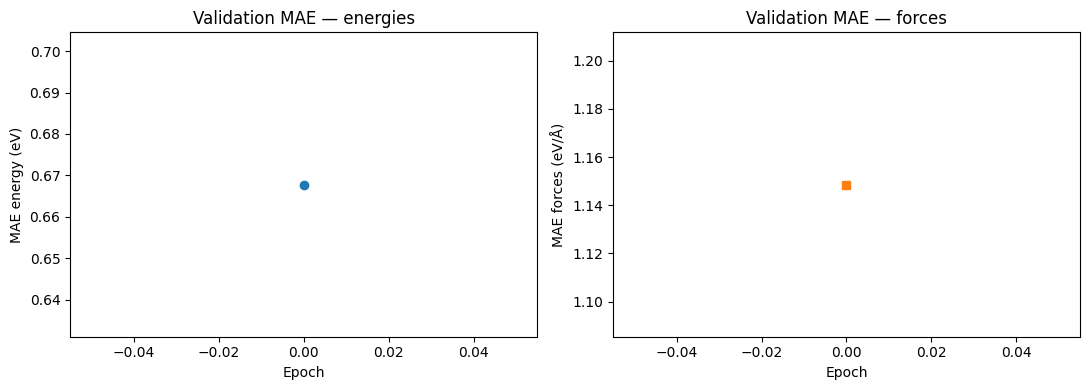

In [31]:
import json, glob, os
import matplotlib.pyplot as plt

def parse_results(path):
    """Read eval entries from an X-MACE results/*_train.txt file."""
    metrics = {}                   # epoch -> (mae_e, mae_f)
    with open(path) as fh:
        for line in fh:
            d = json.loads(line)
            if d["mode"] != "eval" or d["epoch"] is None:
                continue           # skip opt steps and the initial evaluation
            metrics[d["epoch"]] = (d["mae_e"], d["mae_f"])
    epochs = sorted(metrics)
    return (epochs,
            [metrics[e][0] for e in epochs],
            [metrics[e][1] for e in epochs])

def show_eval_entries(path):
    """Diagnostic: print every eval entry. More than one 'run start' block
    means the file mixes several runs (same NAME re-used)."""
    print(f"\nEval entries in {os.path.basename(path)}:")
    for n, line in enumerate(open(path)):
        d = json.loads(line)
        if d["mode"] != "eval":
            continue
        tag = "run start" if d["epoch"] is None else f"epoch {d['epoch']}"
        print(f"  line {n:5d} | {tag:>9} | loss {d['loss']:.3e}"
              f" | mae_e {d['mae_e']:.2f} | mae_f {d['mae_f']:.2f}"
              + (f" | mae_nacs {d['mae_nacs']:.2f}" if "mae_nacs" in d else ""))

results = sorted(glob.glob("X-MACE/results/*_train.txt"), key=os.path.getmtime)
print("Result files found:", results or "none — run section 12 first")

if results:
    path = results[-1]             # most recent run
    show_eval_entries(path)

    epochs, mae_e, mae_f = parse_results(path)
    print(f"\nPlotting {os.path.basename(path)}: {len(epochs)} epoch(s)")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(epochs, mae_e, "o-", color="tab:blue")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("MAE energy (eV)")
    ax1.set_title("Validation MAE — energies")

    ax2.plot(epochs, mae_f, "s-", color="tab:orange")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("MAE forces (eV/Å)")
    ax2.set_title("Validation MAE — forces")

    plt.tight_layout(); plt.show()

# Part 3 — Validation

Training metrics tell us the loss went down — now let's use the model directly.
We load the trained checkpoint as an ASE calculator, predict energies, forces and
NACs on frames from the dataset, and compare them against the reference values.

## 15. Load the Trained Model

Every training run saves a complete model to `X-MACE/checkpoints/<NAME>_run-<seed>.model`.
`MACECalculator` wraps it as an [ASE calculator](https://wiki.fysik.dtu.dk/ase/ase/calculators/calculators.html):
attach it to an `Atoms` object and every energy call runs one forward pass through the
network, returning **all electronic states at once** — energies `(1, n_states)`, forces
`(n_atoms, n_states, 3)` and, for `ExcitedMACE`, NACs `(n_atoms, n_pairs, 3)`.

The cell below picks the **most recently saved** model, so if you just ran the transfer
job that is the one being validated. Set `MODEL_PATH` by hand to compare another.

In [32]:
import glob, os
import numpy as np
from mace.calculators.mace import MACECalculator

models = sorted(glob.glob("X-MACE/checkpoints/*_run-*.model"), key=os.path.getmtime)
print("Models found:", [os.path.basename(m) for m in models] or "none — run section 12 first")

MODEL_PATH = models[-1]            # most recent; set explicitly to pick another
calc = MACECalculator(model_paths=MODEL_PATH, device=DEVICE, n_energies=n_states)
print("Loaded", os.path.basename(MODEL_PATH), "| r_max =", calc.r_max, "| device =", DEVICE)

Models found: ['tutorial_run_run-100.model', 'tutorial_run_transfer_run-100.model']
Loaded tutorial_run_transfer_run-100.model | r_max = 5.0 | device = cpu


## 16. Predict on Sample Frames

We draw random frames from the dataset and predict each one. Two things to know before
comparing:

- **NAC phase.** The sign of a coupling vector follows the arbitrary phase of the
  wavefunctions, so reference and prediction can legitimately disagree by a global
  factor of −1. We align each state pair with the same phase-invariant convention the
  training loss uses.
- **Model variants.** `AutoencoderExcitedMACE` encodes couplings implicitly and returns
  no NAC vectors — the comparison detects this and validates energies and forces only.

*Most of these frames were seen during training, so this is a fit check rather than a
strict test-set evaluation — for that, hold out frames before training.*

In [33]:
def align_phase(ref, pred):
    """NACs carry an arbitrary sign (the wavefunction phase). Return `pred`
    with the sign that best matches `ref` — the same phase-invariant
    convention the training loss uses."""
    if np.sum((ref - pred) ** 2) <= np.sum((ref + pred) ** 2):
        return pred
    return -pred

In [34]:
N_EVAL = 60  #@param {type:"integer"}
rng = np.random.default_rng(0)
idx = rng.choice(len(db), size=min(N_EVAL, len(db)), replace=False)

E_ref, E_pred, F_ref, F_pred, N_ref, N_pred = [], [], [], [], [], []
has_nacs = None

for i in idx:
    atoms = db[int(i)]
    atoms.calc = calc
    atoms.get_potential_energy()             # one forward pass per frame

    E_pred.append(calc.results["energy"].ravel())
    E_ref.append(np.array(atoms.info[ENERGY_KEY]).ravel())
    F_pred.append(calc.results["forces"])
    F_ref.append(np.array(atoms.info[FORCES_KEY]))

    nac_p = calc.results.get("nacs")
    if has_nacs is None:                     # decide once, on the first frame
        has_nacs = nac_p is not None and np.ndim(nac_p) == 3 and NAC_KEY is not None
        if not has_nacs:
            print("Model does not output NAC vectors (AutoencoderExcitedMACE) — "
                  "validating energies and forces only.")
    if has_nacs:
        nac_r = np.array(atoms.info[NAC_KEY])
        for p in range(nac_r.shape[1]):      # one comparison per state pair
            N_ref.append(nac_r[:, p, :].ravel())
            N_pred.append(align_phase(nac_r[:, p, :], nac_p[:, p, :]).ravel())

print(f"Predicted {len(idx)} frames.")

Predicted 60 frames.


## 17. Error Metrics and Parity Plots

A parity plot puts reference values on the x-axis and predictions on the y-axis — a
perfect model lands every point on the diagonal. Things to look for: a vertical offset in
the energies (a constant shift, often harmless), a slope error in the forces (systematic
over- or under-shooting), and scatter far from the line (regions the model hasn't
learned — typically near the conical intersection, where the largest NACs live).

In [35]:
E_ref_all, E_pred_all = np.array(E_ref), np.array(E_pred)
F_ref_all = np.concatenate([f.ravel() for f in F_ref])
F_pred_all = np.concatenate([f.ravel() for f in F_pred])

print(f"MAE energy : {np.abs(E_ref_all - E_pred_all).mean():.3f} eV")
print(f"MAE forces : {np.abs(F_ref_all - F_pred_all).mean():.3f} eV/\u00c5")

panels = [((E_ref_all.ravel(), E_pred_all.ravel()), "Energies", "eV"),
          ((F_ref_all, F_pred_all), "Force components", "eV/\u00c5")]
if has_nacs:
    N_ref_all, N_pred_all = np.concatenate(N_ref), np.concatenate(N_pred)
    print(f"MAE NACs   : {np.abs(N_ref_all - N_pred_all).mean():.3f} (phase-aligned)")
    panels.append(((N_ref_all, N_pred_all), "NAC components (phase-aligned)", "a.u."))

MAE energy : 0.648 eV
MAE forces : 1.086 eV/Å
MAE NACs   : 1.450 (phase-aligned)


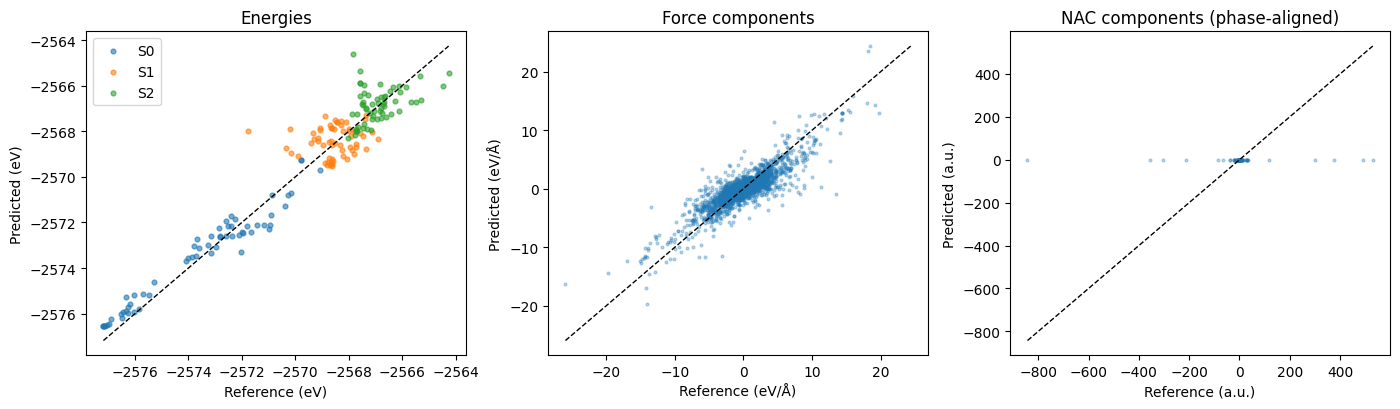

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(panels), figsize=(4.7 * len(panels), 4.2))
for s in range(E_ref_all.shape[1]):
    axes[0].scatter(E_ref_all[:, s], E_pred_all[:, s], s=12, alpha=0.6, label=f"S{s}")
axes[0].legend()
for ax, ((r, q), title, unit) in zip(axes, panels):
    if ax is not axes[0]:
        ax.scatter(r, q, s=4, alpha=0.3, color="tab:blue")
    lo, hi = min(r.min(), q.min()), max(r.max(), q.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel(f"Reference ({unit})"); ax.set_ylabel(f"Predicted ({unit})")
    ax.set_title(title)
plt.tight_layout(); plt.show()

---
# Part 4 — Running Surface Hopping Trajectories

You have a trained model. Now use it to run **nonadiabatic molecular dynamics**: an ensemble
of surface hopping trajectories that let CH2NH2+ evolve on its excited states and hop
between them, with every energy, force and coupling coming from your model instead of a
quantum-chemistry code.

The dynamics engine is [SHARC 4](https://github.com/sharc-md/sharc4). The steps are:

```
build SHARC (18)  →  set up the trajectory folders (19)  →  run them (20-21)  →  plot populations (22)
```

## 18. Build SHARC

SHARC has a compiled Fortran core, so this cell builds it (a few minutes, once). To avoid
rebuilding every time Colab resets, it **saves the result to your Google Drive** and
restores it instantly on later runs. Set `USE_DRIVE_CACHE = False` to skip Drive and just
rebuild each session.

The cell also copies in X-MACE's SHARC interface (`SHARC_MACE.py`) so that `driver.py -i mace`
works, and sets a default `nac_key` on the calculator (the released version forgets to set
one, which would otherwise crash any run that uses couplings).

In [37]:
#@title Build SHARC (or restore it from Drive) { run: "auto" }
USE_DRIVE_CACHE = False   #@param {type:"boolean"}

import os
SHARC_DIR = "/content/sharc4"
CACHE     = "/content/drive/MyDrive/xmace_cache/sharc4.tar.gz"

# Mount Drive (optional) so the build can be cached across sessions.
if USE_DRIVE_CACHE:
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs(os.path.dirname(CACHE), exist_ok=True)

# Runtime libraries and Python packages driver.py needs (every session).
!apt-get install -y -qq libgfortran5 libblas3 liblapack3 libfftw3-double3 libhdf5-103-1t64 libnetcdf19t64 >/dev/null 2>&1
!pip install -q pyscf pyparsing netcdf4 numba pyyaml ase opt_einsum threadpoolctl

if USE_DRIVE_CACHE and os.path.exists(CACHE):
    print("Restoring SHARC from Drive...")
    !tar -xzf "$CACHE" -C /content
else:
    print("Building SHARC from source (first time only)...")
    !apt-get install -y -qq gfortran libblas-dev liblapack-dev libfftw3-dev libnetcdf-dev libhdf5-dev >/dev/null 2>&1
    !git clone -q --depth 1 https://github.com/sharc-md/sharc4.git $SHARC_DIR

    # Configure the Makefile for Colab's GNU toolchain (the defaults target Intel/MKL).
    !sed -i 's/USE_COMPILER := intel/USE_COMPILER := gnu/; s/USE_LIBS := mkl/USE_LIBS := gnu/' $SHARC_DIR/source/Makefile
    !sed -i 's/==\s*\.true\./.eqv..true./g; s/==\s*\.false\./.eqv..false./g' $SHARC_DIR/source/data_extractor_NetCDFmodule.f90

    # Rewrite the NetCDF/HDF5 linker block to Ubuntu's paths. It spans several lines with
    # `\` continuations, so match the whole block at once rather than line by line.
    import re
    mk = f"{SHARC_DIR}/source/Makefile"
    txt = open(mk).read()
    block = re.search(r'NETCDF_LIB = -L\$\(ANACONDA\)/lib.*?-lnetcdf \n', txt, re.S).group(0)
    txt = txt.replace(block, "NETCDF_LIB = -L/usr/lib/x86_64-linux-gnu/hdf5/serial "
                             "-lhdf5 -lhdf5_hl -L../pysharc/lib -lsharcnc -lnetcdf\n")
    open(mk, "w").write(txt)

    # Build (pysharc before source), then put the sharc python package where SHARC expects it.
    !cd $SHARC_DIR/pysharc && make install
    !cd $SHARC_DIR/source  && make install
    !cp -r $SHARC_DIR/pysharc/sharc $SHARC_DIR/lib/

    if USE_DRIVE_CACHE:
        !tar -czf "$CACHE" -C /content sharc4/bin sharc4/lib

# Add the X-MACE interface so `driver.py -i mace` can find it.
!cp X-MACE/scripts/SHARC_MACE.py $SHARC_DIR/lib/

# Point the environment at SHARC (the persistent version of `source sharcvars.sh`).
os.environ["SHARC"]           = f"{SHARC_DIR}/bin"
os.environ["PYTHONPATH"]      = f"{SHARC_DIR}/lib:"  + os.environ.get("PYTHONPATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{SHARC_DIR}/lib:"  + os.environ.get("LD_LIBRARY_PATH", "")

# One-line fix for the released calculator: give it a default nac_key.
from mace.calculators.sharc_calculator import SharcCalculator
SharcCalculator.nac_key = "smooth_nacs"

print("SHARC ready.")

Building SHARC from source (first time only)...
fatal: destination path '/content/sharc4' already exists and is not an empty directory.


AttributeError: 'NoneType' object has no attribute 'group'

## 19. Set up the trajectory folders

The repo ships a ready-made ensemble of starting points for CH2NH2+ (each `TRAJ_N` folder
has a starting geometry, velocities, and a SHARC `input` file). We unzip them and drop a
small `MACE.template` into each one telling SHARC to use **your** model.

In [23]:
import os, glob

# Unzip the example trajectories into a working folder.
WORK = "/content/xmace_run"
!mkdir -p $WORK && unzip -q -o X-MACE/tutorials/ch2nh2_example_trajectories.zip -d $WORK

# The zip contains one parent folder holding the TRAJ_* directories; find it.
ENSEMBLE = next(p for p in glob.glob(f"{WORK}/*") if glob.glob(f"{p}/TRAJ_*"))
os.environ["ENSEMBLE"] = ENSEMBLE

# The model you trained in Part 3 (MODEL_PATH). Fall back to the newest checkpoint on disk.
try:
    model = os.path.abspath(MODEL_PATH)
except NameError:
    # Fall back to the newest DYNAMICS checkpoint. Exclude the Part 5 spectra model:
    # it is trained on propene (no nitrogen!) with 6 outputs and cannot run CH2NH2+.
    candidates = [m for m in glob.glob("X-MACE/checkpoints/*.model")
                  if "propene" not in os.path.basename(m)]
    if not candidates:
        raise FileNotFoundError("No dynamics model found - run Part 2 training first.")
    model = os.path.abspath(sorted(candidates, key=os.path.getmtime)[-1])

template = f"""model_file {model}
device cpu
cutoff 10.0
properties energy forces smooth_nacs
energy_unit eV
distance_unit Ang
"""

# SHARC runs the interface inside each trajectory's QM/ subfolder, so the interface
# files must live there -- not in the TRAJ_* folder itself.
for d in glob.glob(f"{ENSEMBLE}/TRAJ_*"):
    os.makedirs(f"{d}/QM", exist_ok=True)
    open(f"{d}/QM/MACE.template", "w").write(template)
    open(f"{d}/QM/MACE.resources", "w").close()
    if os.path.exists(f"{d}/QM.in"):
        os.remove(f"{d}/QM.in")

print(f"{len(glob.glob(f'{ENSEMBLE}/TRAJ_*'))} folders ready, using model:\n{model}")

70 folders ready, using model:
/content/X-MACE/checkpoints/tutorial_run_run-100.model


## 20. Run one trajectory

Run a single trajectory first to check everything works. `driver.py` loads the model once,
then propagates 100 fs (about 200 steps). In `output.lis`, the active state (column 3)
should start high and hop downward, and the total energy should stay roughly constant.

In [39]:
%%bash
cd "$ENSEMBLE/TRAJ_1"
# SHARC writes its own output.log, so send the driver's output to a SEPARATE file --
# otherwise SHARC's Fortran log overwrites the Python traceback and hides the error.
$SHARC/driver.py -i mace input > driver.log 2>&1

echo "Model used by this folder:"
grep model_file QM/MACE.template

if grep -q -v '^#' output.lis 2>/dev/null; then
    echo "OK -- first steps (step, time, active state, energies...):"
    grep -v '^#' output.lis | head -n 3
else
    echo "=== driver.log (Python side -- the real error is usually here) ==="
    tail -n 25 driver.log
    echo
    echo "=== output.log (SHARC side) ==="
    tail -n 5 output.log
fi


Model used by this folder:
model_file /content/X-MACE/checkpoints/tutorial_run_run-100.model
OK -- first steps (step, time, active state, energies...):
         0         0.0000       3       3       1.619048      10.066440      11.685488       0.000183       0.392199       1.000000     541.499386       0.000000            1
         1         0.5000       3       3       1.628547      10.057305      11.685852       0.000183       0.391906       1.000000     541.499386       0.000000            1
         2         1.0000       3       3       1.638876      10.046717      11.685593       0.000183       0.388595       1.000000     541.499386       0.000000            0


## 21. Run the ensemble

Each trajectory is independent, so we run several at once. Rerunning this cell skips
folders that already finished, so it's safe to resume after an interruption. Increase
`N_TRAJ` to run more (the zip has 70); a handful is enough to see the mechanism.

In [25]:
#@title Run trajectories { run: "auto" }
N_TRAJ = 10   #@param {type:"integer"}

import glob, os
trajs = sorted(glob.glob(f"{ENSEMBLE}/TRAJ_*"),
               key=lambda p: int(p.split("_")[-1]))[:N_TRAJ]

finished, failed = [], []
for d in trajs:
    name = os.path.basename(d)

    # A trajectory counts as finished only if output.lis has real data rows,
    # not just header lines (a crashed run leaves an empty output.lis behind).
    lis = f"{d}/output.lis"
    if os.path.exists(lis) and any(not l.startswith("#") for l in open(lis)):
        finished.append(name)
        print(name, "already done")
        continue

    print(name, "running...")
    os.system(f'cd "{d}" && $SHARC/driver.py -i mace input > output.log 2>&1')

    # Check whether it actually produced data; if not, it failed.
    if os.path.exists(lis) and any(not l.startswith("#") for l in open(lis)):
        finished.append(name)
    else:
        failed.append(name)
        print(f"  {name} FAILED — last lines of its output.log:")
        log = f"{d}/output.log"
        if os.path.exists(log):
            print("   " + "   ".join(open(log).readlines()[-3:]))

print(f"\nFinished: {len(finished)}   Failed: {len(failed)}")
if failed:
    print("Some trajectories failed — see the output.log lines above (often a model-path")
    print("or unit problem in MACE.template). Fix that before plotting populations.")


TRAJ_1 already done
TRAJ_3 running...
TRAJ_4 running...
TRAJ_5 running...
TRAJ_6 running...
TRAJ_7 running...
TRAJ_8 running...
TRAJ_9 running...
TRAJ_10 running...
TRAJ_15 running...

Finished: 10   Failed: 0


## 22. Plot the state populations

The main result is how the electronic-state populations evolve, averaged over the ensemble
— showing CH2NH2+ decaying from S2 down to S0 through the conical intersections you saw in
Part 1.

Instead of calling SHARC's interactive `populations.py`, the cell below reads the finished
`output.lis` files directly (the same "mode 1" classical-population analysis, just done in a
few lines of Python). It skips any trajectory that didn't produce data, so it won't crash if
some runs failed — it simply averages over the ones that finished. With only a few short
trajectories the curves are noisy; run more in Section 21 for a cleaner picture.

In [40]:
import glob, os
import numpy as np

def compute_populations(ensemble_dir, n_states=3, dt=0.5, tmax=100.0):
    """Ensemble state populations from SHARC output.lis files.

    This is the classical-population analysis that SHARC's populations.py does in
    its "mode 1", reimplemented directly so no interactive script call is needed.
    Each line of output.lis is one timestep whose 3rd column is the active state;
    at every timestep we count how many trajectories are in each state. A trajectory
    that ends early is held in its final state so the populations stay normalised.

    Returns (times, populations, n_traj), where populations[i, s] is the fraction of
    the ensemble in state s at times[i].
    """
    lis_files = sorted(glob.glob(f"{ensemble_dir}/TRAJ_*/output.lis"))
    nsteps = int(tmax / dt) + 1
    counts = np.zeros((nsteps, n_states))
    n_traj = 0

    for path in lis_files:
        # active state (column index 2, 1-based in SHARC) at each step
        states = [int(l.split()[2]) - 1
                  for l in open(path)
                  if not l.startswith("#") and len(l.split()) >= 3]
        if not states:
            continue                      # crashed/empty trajectory -> skip
        n_traj += 1
        for step in range(nsteps):
            s = states[step] if step < len(states) else states[-1]
            counts[step, s] += 1

    if n_traj == 0:
        raise RuntimeError("No finished trajectories found - run Section 21 first.")

    times = np.arange(nsteps) * dt
    return times, counts / n_traj, n_traj


# The example inputs use 3 singlet states, a 0.5 fs step and run to 100 fs.
times, populations, n_traj = compute_populations(ENSEMBLE, n_states=3, dt=0.5, tmax=100.0)
print(f"Averaged over {n_traj} trajectories.")

Averaged over 10 trajectories.


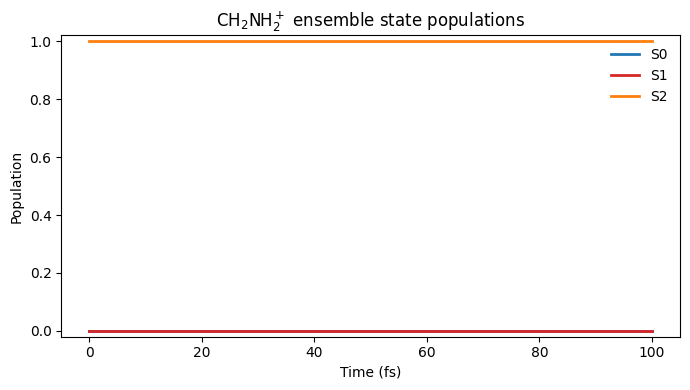

In [27]:
import matplotlib.pyplot as plt

# Colour palette borrowed from X-MACE's own plot_train.py, for a consistent look.
colors = ["#1f77b4", "#d62728", "#ff7f0e", "#2ca02c", "#9467bd", "#8c564b"]

plt.figure(figsize=(7, 4))
for s in range(populations.shape[1]):
    plt.plot(times, populations[:, s], color=colors[s % len(colors)],
             lw=2, label=f"S{s}")
plt.xlabel("Time (fs)")
plt.ylabel("Population")
plt.title("CH$_2$NH$_2^+$ ensemble state populations")
plt.ylim(-0.02, 1.02)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

---
# Part 5 — Predicting Absorption Spectra

Dynamics is not the only thing an excited-state model can do. This part trains a model to
predict **vertical excitation energies and oscillator strengths**, and uses it to build a
**UV/Vis absorption spectrum** — for a new molecule, propene (C3H6).

### The nuclear ensemble method

A molecule doesn't absorb from a single geometry: even in its ground state it vibrates, and
every distorted geometry has slightly different excitation energies ΔE_i and transition
intensities (oscillator strengths f_i). The absorption spectrum is the sum over an ensemble
of geometries of "stick" transitions f_i at energies ΔE_i, broadened by narrow Gaussians:

```
S(E)  =  Σ_geometries  Σ_states   f_i · exp( -(E - ΔE_i)² / 2σ² )
```

Computing ΔE and f quantum-chemically for thousands of geometries is expensive — which is
exactly where a model comes in.

### The training trick: intensities as extra "energies"

Oscillator strengths are geometry-dependent **global scalars per state — just like
energies**. So instead of new architecture, we pack both into the energy field: each frame's
`REF_energy` holds six values, `[ΔE1, ΔE2, ΔE3, f1, f2, f3]`, and the model is trained with
`--n_energies=6` and `--forces_weight=0` (intensities have no forces). The multi-state
energy machinery learns all six scalars at once.

## 23. Get the propene data

The repo ships a ready-made dataset, `tutorials/propene_spectra.zip`, with three files:

| File | Contents |
|---|---|
| `train_osc_data.xyz` | 700 propene geometries with `REF_energy = [ΔE1, ΔE2, ΔE3, f1, f2, f3]` (eV / dimensionless) |
| `test_osc_data.xyz`  | 300 held-out geometries, same layout |
| `deltaE_osc.pkl`     | precomputed model predictions for the test set (used as a fallback below) |

In [41]:
import os, glob
import numpy as np
import ase.io

SPEC = "/content/propene_opt"
!unzip -q -o X-MACE/tutorials/propene_opt.zip -d /content

train = ase.io.read(f"{SPEC}/train_osc_data.xyz", ":")
test  = ase.io.read(f"{SPEC}/test_osc_data.xyz", ":")
print(f"train: {len(train)} frames | test: {len(test)} frames | {train[0].get_chemical_formula()}")

vals = np.array(train[0].info["REF_energy"]).reshape(-1)
print("REF_energy of frame 0:", np.round(vals, 4))
print("  excitation energies (eV):", np.round(vals[:3], 3))
print("  oscillator strengths    :", np.round(vals[3:], 4))

train: 700 frames | test: 300 frames | C3H6
REF_energy of frame 0: [8.75520e+00 1.33655e+01 4.61030e+00 7.19000e-02 7.00000e-04 8.16000e-02]
  excitation energies (eV): [ 8.755 13.366  4.61 ]
  oscillator strengths    : [0.0719 0.0007 0.0816]


## 24. Train the spectra model

Identical machinery to Part 2 with three changes: `--n_energies=6` (three ΔE + three f per
frame), `--forces_weight=0.0` (no forces exist for intensities), and `--energy_weight=100.0`
as the only loss term. 700 small frames train quickly — a couple of minutes on a GPU.

In [51]:
#@title Train the spectra model { run: "auto" }
OSC_EPOCHS = 5   #@param {type:"integer"}

import subprocess, os
cmd = f"""python X-MACE/scripts/run_train.py \
  --name="propene_spectra" \
  --model_dir="X-MACE/checkpoints" \
  --checkpoints_dir="X-MACE/checkpoints" \
  --log_dir="X-MACE/logs" \
  --results_dir="X-MACE/results" \
  --train_file="{SPEC}/train_osc_data.xyz" \
  --seed=100 \
  --valid_fraction=0.1 \
  --E0s='average' \
  --model="ExcitedMACE" \
  --r_max=5.0 \
  --batch_size=10 \
  --n_energies=6 \
  --correlation=3 \
  --max_num_epochs={OSC_EPOCHS} \
  --ema --lr=0.001 --ema_decay=0.99 \
  --default_dtype="float32" \
  --device={"cuda" if os.environ.get("COLAB_GPU") else "cpu"} \
  --hidden_irreps="32x0e + 32x1o" \
  --MLP_irreps='32x0e' \
  --num_radial_basis=8 \
  --num_interactions=2 \
  --energy_weight=100.0 \
  --forces_weight=0.0 \
  --error_table="EnergyNacsDipoleMAE"
"""
print(cmd)
proc = subprocess.Popen(
    cmd, shell=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,   # mace logs via stderr — merge it in
    text=True, bufsize=1,
)
for line in proc.stdout:        # streams live into the cell output
    print(line, end="")
proc.wait()

python X-MACE/scripts/run_train.py   --name="propene_spectra"   --model_dir="X-MACE/checkpoints"   --checkpoints_dir="X-MACE/checkpoints"   --log_dir="X-MACE/logs"   --results_dir="X-MACE/results"   --train_file="/content/propene_opt/train_osc_data.xyz"   --seed=100   --valid_fraction=0.1   --E0s='average'   --model="ExcitedMACE"   --r_max=5.0   --batch_size=10   --n_energies=6   --correlation=3   --max_num_epochs=5   --ema --lr=0.001 --ema_decay=0.99   --default_dtype="float32"   --device=cpu   --hidden_irreps="32x0e + 32x1o"   --MLP_irreps='32x0e'   --num_radial_basis=8   --num_interactions=2   --energy_weight=100.0   --forces_weight=0.0   --error_table="EnergyNacsDipoleMAE"

2026-07-29 13:18:21.905 INFO: ===========VERIFYING SETTINGS===========
2026-07-29 13:18:21.906 INFO: MACE version: 0.3.6
2026-07-29 13:18:21.906 INFO: Using CPU
2026-07-29 13:18:21.957 INFO: 
2026-07-29 13:18:21.958 INFO: ===========LOADING INPUT DATA===========
2026-07-29 13:18:22.188 INFO: Using random 10% of 

0

## 25. Predict the test set

The trained model is used through the same `MACECalculator` as everywhere else — just with
`n_energies=6`. Each prediction returns six numbers per geometry, which we split back into
energies and intensities.

If you skipped training, this cell falls back to `deltaE_osc.pkl` — predictions from a
reference model — so the spectrum comparison below always works.

predicted 300 frames with propene_spectra.model


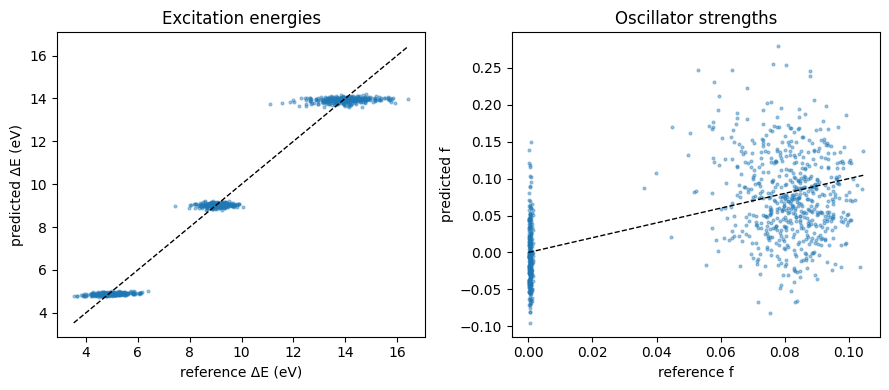

In [52]:
import pickle, glob, os
import numpy as np

osc_models = sorted(glob.glob("X-MACE/checkpoints/propene_spectra*.model"), key=os.path.getmtime)

if osc_models:
    from mace.calculators import MACECalculator
    calc = MACECalculator(model_paths=osc_models[-1], n_energies=6, device="cpu")
    pred = []
    for mol in test:
        calc.calculate(mol)
        pred.append(np.array(calc.results["energy"]).reshape(-1))
    pred = np.array(pred)
    print(f"predicted {len(pred)} frames with {os.path.basename(osc_models[-1])}")
else:
    pred = np.array([np.reshape(v, -1) for v in pickle.load(open(f"{SPEC}/deltaE_osc.pkl", "rb"))])
    print(f"no trained model found — using {len(pred)} precomputed predictions from deltaE_osc.pkl")

ref = np.array([np.reshape(m.info["REF_energy"], -1) for m in test])

# quick parity check: energies (first 3 columns) and intensities (last 3)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].scatter(ref[:, :3], pred[:, :3], s=4, alpha=0.4)
ax[0].plot([ref[:, :3].min(), ref[:, :3].max()], [ref[:, :3].min(), ref[:, :3].max()], "k--", lw=1)
ax[0].set(xlabel="reference ΔE (eV)", ylabel="predicted ΔE (eV)", title="Excitation energies")
ax[1].scatter(ref[:, 3:], pred[:, 3:], s=4, alpha=0.4)
ax[1].plot([ref[:, 3:].min(), ref[:, 3:].max()], [ref[:, 3:].min(), ref[:, 3:].max()], "k--", lw=1)
ax[1].set(xlabel="reference f", ylabel="predicted f", title="Oscillator strengths")
plt.tight_layout(); plt.show()

## 26. Build the absorption spectrum

Every geometry contributes three sticks (f_i at ΔE_i); Gaussian-broadening and summing over
the ensemble gives the spectrum. Plotting reference against prediction shows how well the
model reproduces the band shape — with 300 geometries the main band and its width should
match closely.

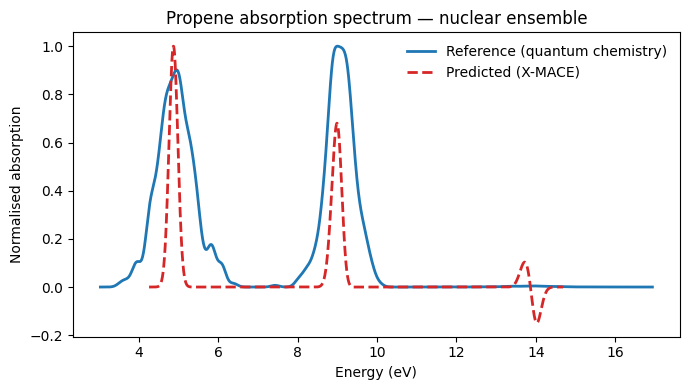

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def broaden_spectrum(energies_eV, f, sigma_eV=0.1, E_min=None, E_max=None, points=2000):
    """Gaussian-broadened sum of stick transitions (f_i at energies_eV_i), normalised."""
    energies_eV, f = np.asarray(energies_eV).ravel(), np.asarray(f).ravel()
    if E_min is None: E_min = energies_eV.min() - 0.5
    if E_max is None: E_max = energies_eV.max() + 0.5
    E = np.linspace(E_min, E_max, points)
    S = np.zeros_like(E)
    for Ei, fi in zip(energies_eV, f):
        S += fi * np.exp(-0.5 * ((E - Ei) / sigma_eV) ** 2)
    return E, S / S.max()

E_ref,  S_ref  = broaden_spectrum(ref[:, :3],  ref[:, 3:])
E_pred, S_pred = broaden_spectrum(pred[:, :3], pred[:, 3:])

plt.figure(figsize=(7, 4))
plt.plot(E_ref,  S_ref,  label="Reference (quantum chemistry)", color="#1f77b4", lw=2)
plt.plot(E_pred, S_pred, label="Predicted (X-MACE)", color="#d62728", lw=2, ls="--")
plt.xlabel("Energy (eV)"); plt.ylabel("Normalised absorption")
plt.title("Propene absorption spectrum — nuclear ensemble")
plt.legend(frameon=False); plt.tight_layout(); plt.show()

### Notes and extensions

* **Broadening width**: σ = 0.1 eV is a phenomenological choice; smaller σ reveals ensemble
  structure, larger σ smooths it. It stands in for finite lifetime and instrument response,
  not physics the model knows about.
* **What's approximated**: the nuclear ensemble method captures band positions and widths
  from geometry sampling, but not vibronic fine structure (no Franck–Condon progression).
* **Your own molecule**: sample ground-state geometries (e.g. a Wigner distribution from a
  frequency calculation, as in the initial-conditions tutorial), compute ΔE and f with your
  reference method for a few hundred of them, pack them exactly like `train_osc_data.xyz`,
  and everything above transfers unchanged.

That's the full tour: **one framework — dataset → dynamics (Parts 1–4) → spectroscopy (Part 5).**